### Agentic RAG

In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")

In [2]:
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings
from langchain_ollama import OllamaEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter

C:\Users\harsh\AppData\Local\Temp\ipykernel_5040\1200860716.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import WebBaseLoader
d:\Anaconda3\envs\LangChain_Langgraph_Course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
USER_AGENT environment variable not set, consider setting it to identify your requests.


In [3]:
urls=[
    "https://langchain-ai.github.io/langgraph/tutorials/introduction/",
    "https://langchain-ai.github.io/langgraph/tutorials/workflows/",
    "https://langchain-ai.github.io/langgraph/how-tos/map-reduce/"
]

docs=[WebBaseLoader(url).load() for url in urls]
docs

[[Document(metadata={'source': 'https://langchain-ai.github.io/langgraph/tutorials/introduction/', 'title': 'Redirecting...', 'language': 'en'}, page_content='\n\n\n\nRedirecting...\n\n\n\n\n\n\nRedirecting...\n\n\n')],
 [Document(metadata={'source': 'https://langchain-ai.github.io/langgraph/tutorials/workflows/', 'title': 'Redirecting...', 'language': 'en'}, page_content='\n\n\n\nRedirecting...\n\n\n\n\n\n\nRedirecting...\n\n\n')],
 [Document(metadata={'source': 'https://langchain-ai.github.io/langgraph/how-tos/map-reduce/', 'title': 'Redirecting...', 'language': 'en'}, page_content='\n\n\n\nRedirecting...\n\n\n\n\n\n\nRedirecting...\n\n\n')]]

In [4]:
docs_list = [item for sublist in docs for item in sublist]

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000, chunk_overlap=100
)

doc_splits = text_splitter.split_documents(docs_list)

## Add all these text to vectordb

vectorstore=FAISS.from_documents(
    documents = doc_splits,
    embedding = OllamaEmbeddings(model="nomic-embed-text")
)


retriever=vectorstore.as_retriever()

In [5]:
print(doc_splits)

[Document(metadata={'source': 'https://langchain-ai.github.io/langgraph/tutorials/introduction/', 'title': 'Redirecting...', 'language': 'en'}, page_content='Redirecting...\n\n\n\n\n\n\nRedirecting...'), Document(metadata={'source': 'https://langchain-ai.github.io/langgraph/tutorials/workflows/', 'title': 'Redirecting...', 'language': 'en'}, page_content='Redirecting...\n\n\n\n\n\n\nRedirecting...'), Document(metadata={'source': 'https://langchain-ai.github.io/langgraph/how-tos/map-reduce/', 'title': 'Redirecting...', 'language': 'en'}, page_content='Redirecting...\n\n\n\n\n\n\nRedirecting...')]


In [6]:
retriever.invoke("what is langgraph")

[Document(id='7fa24c36-03ab-4708-af37-eee1c6cf6a43', metadata={'source': 'https://langchain-ai.github.io/langgraph/tutorials/introduction/', 'title': 'Redirecting...', 'language': 'en'}, page_content='Redirecting...\n\n\n\n\n\n\nRedirecting...'),
 Document(id='8bd226c3-2609-419a-b23c-a512d3af5d37', metadata={'source': 'https://langchain-ai.github.io/langgraph/tutorials/workflows/', 'title': 'Redirecting...', 'language': 'en'}, page_content='Redirecting...\n\n\n\n\n\n\nRedirecting...'),
 Document(id='ad4c69e7-9218-47a9-b446-6962250c8a61', metadata={'source': 'https://langchain-ai.github.io/langgraph/how-tos/map-reduce/', 'title': 'Redirecting...', 'language': 'en'}, page_content='Redirecting...\n\n\n\n\n\n\nRedirecting...')]

In [7]:
### Retriever To Retriever Tools
from langchain_core.tools import create_retriever_tool

retriever_tool=create_retriever_tool(
    retriever,
    "retriever_vector_db_blog",
    "Search and run information about Langgraph"
)

In [8]:
retriever_tool

StructuredTool(name='retriever_vector_db_blog', description='Search and run information about Langgraph', args_schema=<class 'langchain_core.tools.retriever.RetrieverInput'>, func=<function create_retriever_tool.<locals>.func at 0x000001E523A05BC0>, coroutine=<function create_retriever_tool.<locals>.afunc at 0x000001E523A05C60>)

### Langchain Blogs- Seperate Vector Store


In [9]:
langchain_urls=[
    "https://python.langchain.com/docs/tutorials/",
    "https://python.langchain.com/docs/tutorials/chatbot/",
    "https://python.langchain.com/docs/tutorials/qa_chat_history/"
]

docs=[WebBaseLoader(url).load() for url in langchain_urls]
docs

[[Document(metadata={'source': 'https://python.langchain.com/docs/tutorials/', 'title': 'LangChain overview - Docs by LangChain', 'description': 'LangChain provides create_agent: a minimal, highly configurable agent harness. Compose exactly the agent your use case needs from model, tools, prompt, and middleware.', 'language': 'en'}, page_content='LangChain overview - Docs by LangChainDocumentation IndexFetch the complete documentation index at: /llms.txtUse this file to discover all available pages before exploring further.Skip to main contentInterrupt is coming to NYC and London this fall. Join the builders, engineers, and teams shaping what\'s next for agents. Get your tickets →Docs by LangChain home pageBuildSearch...⌘KAsk AIGitHubTry LangSmithTry LangSmithSearch...NavigationLangChain overviewOverviewDeep AgentsLangChainLangGraphIntegrationsLearnReferenceContributePythonOverviewGet startedInstallQuickstartChangelogPhilosophyCore componentsAgentsModelsMessagesToolsShort-term memoryEv

In [10]:
docs_list = [item for sublist in docs for item in sublist]

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000, chunk_overlap=100
)

doc_splits = text_splitter.split_documents(docs_list)

## Add all these text to vectordb

vectorstorelangchain=FAISS.from_documents(
    documents=doc_splits,
    embedding=OllamaEmbeddings(model="nomic-embed-text")
)


retrieverlangchain=vectorstorelangchain.as_retriever()

In [11]:
from langchain_core.tools import create_retriever_tool

retriever_tool_langchain=create_retriever_tool(
    retrieverlangchain,
    "retriever_vector_langchain_blog",
    "Search and run information about Langchain"
)

In [12]:
tools=[retriever_tool,retriever_tool_langchain]

### LangGraph Workflow

In [13]:
from typing import Annotated, Sequence
from typing_extensions import TypedDict

from langchain_core.messages import BaseMessage

from langgraph.graph.message import add_messages


class AgentState(TypedDict):
    # The add_messages function defines how an update should be processed
    # Default is to replace. add_messages says "append"
    messages: Annotated[Sequence[BaseMessage], add_messages]

In [14]:
from langchain_groq import ChatGroq

llm = ChatGroq(model="qwen/qwen3.6-27b")
llm.invoke("Hi")

AIMessage(content='\n<think>\nHere\'s a thinking process:\n\n1.  **Analyze User Input:** The user said "Hi". This is a standard greeting.\n2.  **Identify Intent:** The user is initiating a conversation. No specific question or task is provided.\n3.  **Determine Response Strategy:** \n   - Acknowledge the greeting warmly\n   - Offer assistance\n   - Keep it open-ended to encourage the user to share what they need\n4.  **Draft Response (Mental):** Hello! How can I assist you today? Feel free to ask me anything or let me know what you\'re working on.\n5.  **Refine Response:** Keep it concise, friendly, and professional. Match the tone of the input.\n   "Hello! 👋 How can I help you today?"\n6.  **Final Output Generation:** (Matches the refined response)✅\n</think>\n\nHello! 👋 How can I help you today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 197, 'prompt_tokens': 11, 'total_tokens': 208, 'completion_time': 0.37517629, 'completion_tokens_details': None

In [15]:
def agent(state):
    """
    Invokes the agent model to generate a response based on the current state. Given
    the question, it will decide to retrieve using the retriever tool, or simply end.

    Args:
        state (messages): The current state

    Returns:
        dict: The updated state with the agent response appended to messages
    """
    print("---CALL AGENT---")
    messages = state["messages"]
    model = ChatGroq(model="qwen/qwen3.6-27b")
    model = model.bind_tools(tools)
    response = model.invoke(messages)
    # We return a list, because this will get added to the existing list
    return {"messages": [response]}

In [17]:
from typing import Annotated, Literal, Sequence
from typing_extensions import TypedDict

from langsmith import Client
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import PromptTemplate

from pydantic import BaseModel, Field

hub = Client()

In [18]:
### Edges
def grade_documents(state) -> Literal["generate", "rewrite"]:
    """
    Determines whether the retrieved documents are relevant to the question.

    Args:
        state (messages): The current state

    Returns:
        str: A decision for whether the documents are relevant or not
    """

    print("---CHECK RELEVANCE---")

    # Data model
    class grade(BaseModel):
        """Binary score for relevance check."""

        binary_score: str = Field(description="Relevance score 'yes' or 'no'")

    # LLM
    model = ChatGroq(model="qwen/qwen3.6-27b")

    # LLM with tool and validation
    llm_with_tool = model.with_structured_output(grade)

    # Prompt
    prompt = PromptTemplate(
        template="""You are a grader assessing relevance of a retrieved document to a user question. \n 
        Here is the retrieved document: \n\n {context} \n\n
        Here is the user question: {question} \n
        If the document contains keyword(s) or semantic meaning related to the user question, grade it as relevant. \n
        Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question.""",
        input_variables=["context", "question"],
    )

    # Chain
    chain = prompt | llm_with_tool

    messages = state["messages"]
    last_message = messages[-1]

    question = messages[0].content
    docs = last_message.content

    scored_result = chain.invoke({"question": question, "context": docs})

    score = scored_result.binary_score

    if score == "yes":
        print("---DECISION: DOCS RELEVANT---")
        return "generate"

    else:
        print("---DECISION: DOCS NOT RELEVANT---")
        print(score)
        return "rewrite"

In [29]:
def generate(state):
    """
    Generate answer

    Args:
        state (messages): The current state

    Returns:
         dict: The updated message
    """
    print("---GENERATE---")
    messages = state["messages"]
    question = messages[0].content
    last_message = messages[-1]

    docs = last_message.content

    # Prompt
    prompt = PromptTemplate(
        template="""
        Use the following pieces of retrieved context to answer the question.

        If you don't know the answer, just say that you don't know.

        Question: {question}

        Context:
        {context}

        Answer:
        """,
        input_variables=["context", "question"],
    )

    # LLM
    llm = ChatGroq(model="qwen/qwen3.6-27b")

    # Post-processing
    def format_docs(docs):
        return "\n\n".join(doc.page_content for doc in docs)

    # Chain
    rag_chain = prompt | llm | StrOutputParser()

    # Run
    response = rag_chain.invoke({"context": docs, "question": question})
    return {"messages": [response]}

In [30]:
def rewrite(state):
    """
    Transform the query to produce a better question.

    Args:
        state (messages): The current state

    Returns:
        dict: The updated state with re-phrased question
    """

    print("---TRANSFORM QUERY---")
    messages = state["messages"]
    question = messages[0].content

    msg = [
        HumanMessage(
            content=f""" \n 
    Look at the input and try to reason about the underlying semantic intent / meaning. \n 
    Here is the initial question:
    \n ------- \n
    {question} 
    \n ------- \n
    Formulate an improved question: """,
        )
    ]

    # Grader
    model = ChatGroq(model="qwen/qwen3.6-27b")
    response = model.invoke(msg)
    return {"messages": [response]}

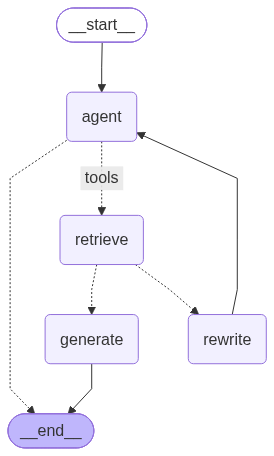

In [31]:
from langgraph.graph import END, StateGraph, START
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

# Define a new graph
workflow = StateGraph(AgentState)

# Define the nodes we will cycle between
workflow.add_node("agent", agent)  # agent
retrieve = ToolNode([retriever_tool,retriever_tool_langchain])
workflow.add_node("retrieve", retrieve)  # retrieval
workflow.add_node("rewrite", rewrite)  # Re-writing the question
workflow.add_node(
    "generate", generate
)  # Generating a response after we know the documents are relevant
# Call agent node to decide to retrieve or not
workflow.add_edge(START, "agent")

# Decide whether to retrieve
workflow.add_conditional_edges(
    "agent",
    # Assess agent decision
    tools_condition,
    {
        # Translate the condition outputs to nodes in our graph
        "tools": "retrieve",
        END: END,
    },
)

# Edges taken after the `action` node is called.
workflow.add_conditional_edges(
    "retrieve",
    # Assess agent decision
    grade_documents,
)
workflow.add_edge("generate", END)
workflow.add_edge("rewrite", "agent")

# Compile
graph = workflow.compile()
from IPython.display import Image, display
display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

In [32]:
graph.invoke({"messages":"What is Langgraph?"})

---CALL AGENT---
---CHECK RELEVANCE---
---DECISION: DOCS NOT RELEVANT---
no
---TRANSFORM QUERY---
---CALL AGENT---


{'messages': [HumanMessage(content='What is Langgraph?', additional_kwargs={}, response_metadata={}, id='029d0e18-1d1e-4d5e-a788-486351682085'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'Thinking Process:\n\n1.  **Analyze the Request:** The user is asking "What is Langgraph?".\n2.  **Identify the Intent:** The user wants a definition and overview of the tool/library called LangGraph.\n3.  **Check Available Tools:**\n    *   `retriever_vector_db_blog`: Search and run information about Langgraph.\n    *   `retriever_vector_langchain_blog`: Search and run information about Langchain.\n4.  **Select the Best Tool:** Since the query is specifically about "Langgraph", the `retriever_vector_db_blog` tool is the most appropriate choice.\n5.  **Formulate the Tool Call:**\n    *   Function: `retriever_vector_db_blog`\n    *   Argument: `query` = "What is Langgraph?" or "Langgraph overview". Let\'s use "What is Langgraph?".\n6.  **Execute the Tool Call.**\n7.  **Process the 

In [33]:
graph.invoke({"messages":"What is Langchain?"})

---CALL AGENT---
---CHECK RELEVANCE---
---DECISION: DOCS RELEVANT---
---GENERATE---


{'messages': [HumanMessage(content='What is Langchain?', additional_kwargs={}, response_metadata={}, id='95acd609-e89e-4ec8-ba60-59e0b842eeba'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'Thinking Process:\n\n1.  **Understand the User\'s Request:** The user is asking "What is Langchain?".\n2.  **Identify the Tool:** I have access to two tools: `retriever_vector_db_blog` (for Langgraph) and `retriever_vector_langchain_blog` (for Langchain). Since the question is about Langchain, I should use `retriever_vector_langchain_blog`.\n3.  **Formulate the Query:** The query should be simple and direct to get a general overview. "What is Langchain" or "Introduction to Langchain" or "Langchain overview".\n4.  **Execute the Tool:** Call `retriever_vector_langchain_blog` with the query "What is Langchain".\n5.  **Process the Output:** Summarize the information retrieved to answer the user\'s question clearly.\n\nLet\'s call the tool.\n', 'tool_calls': [{'id': '4pvkfnw8v', 'func

In [34]:
graph.invoke({"messages":"What is Machine learning?"})

---CALL AGENT---


{'messages': [HumanMessage(content='What is Machine learning?', additional_kwargs={}, response_metadata={}, id='0eb98f49-daac-40ef-b5d1-5f89342d987f'),
  AIMessage(content='**Machine Learning (ML)** is a branch of artificial intelligence (AI) that focuses on building systems that can learn from data, identify patterns, and make decisions or predictions with minimal human intervention. Instead of being explicitly programmed with rigid rules, ML algorithms improve their performance over time as they are exposed to more data.\n\n### 🔑 Core Idea\nTraditional programming follows this pattern:\n`Data + Rules → Program → Answers`\n\nMachine learning flips it:\n`Data + Answers → Program → New Predictions`\n\nThe system "learns" the rules by analyzing examples.\n\n### 🧠 Main Types of Machine Learning\n1. **Supervised Learning**  \n   The model is trained on labeled data (input-output pairs). It learns to map inputs to correct outputs.  \n   *Examples:* Spam detection, image classification, pric